# Notebook 3: Feature Engineering & Exploratory Data Analysis (Revised for Scientific Rigour)
Prepared by Festus Ogungbemiro

## Overview
In this notebook we enrich the DFT data obtained from the Materials Project with **composition‑based descriptors** using `pymatgen`. Instead of arbitrary thresholds, we define antimicrobial activity labels grounded in three well‑established mechanisms:

1. **Ion release** – characteristic of metals like Ag, Cu, Zn.
2. **Photocatalytic ROS generation** – requires a band gap in the visible range (≈1.5–3.0 eV).
3. **Polarity‑driven membrane disruption** – correlates with large electronegativity differences (charge transfer).

We also construct a continuous **potency score** as a weighted combination of descriptors, mimicking QSAR approaches reported in the literature (R² up to 0.957). Finally, we perform exploratory data analysis (correlation, box plots, distributions) and save the enriched dataset for machine learning.

**Key references:**
- [1] **ZnO study**: "variation of bandgap...had no significant impact on the antibacterial activity" (dark conditions). http://ore.immt.res.in/handle/2018/3881 
- [2] **Doped ZnO₂**: band gap reduction from 3.07→2.79 eV enhanced photocatalytic activity. https://eurofarma.ovidds.com/discover/result?logSearchID=197718363&pubid=6057-medline%3A40819011 
- [3] **QSAR on quinolone‑triazoles**: HOMO‑LUMO gap and partial atomic charges were the most significant descriptors. https://www.tandfonline.com/doi/full/10.1080/10799893.2021.1988971
- [4] **General QSAR review**: electronic descriptors (EHOMO, ELUMO, electronegativity) dominate antibacterial models. https://pubmed.ncbi.nlm.nih.gov/28969576/

---
## 1. Install Required Libraries (if not already present)

In [2]:
pip install pymatgen pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


---
## 2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymatgen.core import Composition
from sklearn.preprocessing import MinMaxScaler

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.dpi'] = 150

---
## 3. Load the Raw Data

Load the file `01_materials_project_raw_data.csv` saved from Notebook 2.

In [4]:
df = pd.read_csv("01_materials_project_raw_data.csv")
print(f"Data shape: {df.shape}")
df.head()

Data shape: (55200, 8)


,MPID,Formula,Band_Gap_eV,Formation_Energy_eV_atom,Density_g_cm3,Volume_A3,Is_Metal,Num_Elements
0,mp-989737,Ag,0.0,0.010382,9.922633,54.154786,True,1
1,mp-10597,Ag,0.0,0.007669,10.302467,34.772131,True,1
2,mp-8566,Ag,0.0,0.000000,10.315418,69.456950,True,1
3,mp-124,Ag,0.0,0.002127,10.362567,17.285231,True,1
4,mp-2646971,Ag,0.0,0.034337,9.866742,18.153850,True,1


---
## 4. Feature Engineering with Pymatgen – Literature‑Based Descriptors

We extract from each chemical formula a set of **composition‑weighted elemental properties**. These serve as proxies for the actual compound’s behaviour, acknowledging the limitation that full electronic structure would require DFT on the crystal structure.

### Descriptor set (inspired by QSAR studies [3,4]):
- **Presence of known antimicrobial metals** (`Ag`, `Cu`, `Zn`, `Co`, `Ni`, `Au`, `Pt`, `Pd`) – binary flags and count.
- **Average, maximum, minimum, and range of Pauling electronegativity** – indicators of charge transfer potential.
- **Geometric mean of electronegativity** – approximates the compound’s Mulliken electronegativity.
- **Average atomic number** – rough proxy for electron density.
- **Average atomic mass** – influences ion mobility.
- **Band gap** (already present) – used for photocatalytic mechanism.
- **Formation energy** (already present) – thermodynamic stability, related to ion release tendency.

In [5]:
def extract_descriptors(formula):
    """Return a Series of composition‑based descriptors for a given formula."""
    try:
        comp = Composition(formula)
        elements = comp.elements
        # Atomic numbers, masses, electronegativities
        atomic_numbers = [el.Z for el in elements]
        atomic_masses = [el.atomic_mass for el in elements]
        electroneg = [el.X for el in elements if el.X is not None]

        # Antimicrobial metal list (from literature)
        am_metals = {'Ag', 'Cu', 'Zn', 'Co', 'Ni', 'Au', 'Pt', 'Pd'}
        metal_flags = [1 if el.symbol in am_metals else 0 for el in elements]

        # Fractional composition (amount of each element)
        fracs = [comp.get_atomic_fraction(el) for el in elements]

        # Weighted averages
        avg_Z = np.average(atomic_numbers, weights=fracs)
        avg_mass = np.average(atomic_masses, weights=fracs)

        # Electronegativity handling
        if len(electroneg) > 0:
            avg_EN = np.average(electroneg, weights=[comp.get_atomic_fraction(el) for el in elements if el.X is not None])
            max_EN = np.max(electroneg)
            min_EN = np.min(electroneg)
            range_EN = max_EN - min_EN
            geom_mean_EN = np.exp(np.mean(np.log(electroneg)))   # geometric mean
        else:
            avg_EN = max_EN = min_EN = range_EN = geom_mean_EN = 0

        # Antimicrobial metal summary
        has_am_metal = int(np.sum(metal_flags) > 0)
        num_am_metals = np.sum(metal_flags)

        return pd.Series({
            'Avg_Atomic_Number': avg_Z,
            'Avg_Atomic_Mass': avg_mass,
            'Avg_Electronegativity': avg_EN,
            'Max_Electronegativity': max_EN,
            'Min_Electronegativity': min_EN,
            'Electronegativity_Range': range_EN,
            'Geometric_Mean_EN': geom_mean_EN,
            'Has_Antimicrobial_Metal': has_am_metal,
            'Num_Antimicrobial_Metals': num_am_metals
        })
    except Exception as e:
        print(f"Warning: could not parse {formula}: {e}")
        return pd.Series({
            'Avg_Atomic_Number': 0,
            'Avg_Atomic_Mass': 0,
            'Avg_Electronegativity': 0,
            'Max_Electronegativity': 0,
            'Min_Electronegativity': 0,
            'Electronegativity_Range': 0,
            'Geometric_Mean_EN': 0,
            'Has_Antimicrobial_Metal': 0,
            'Num_Antimicrobial_Metals': 0
        })

# Apply descriptor extraction
desc_df = df['Formula'].apply(extract_descriptors)
df = pd.concat([df, desc_df], axis=1)
print("New descriptors added. Shape:", df.shape)

New descriptors added. Shape: (55200, 17)


---
## 5. Defining Antimicrobial Activity Labels (Mechanism‑Based)

We now create **multiple binary labels** corresponding to different antimicrobial mechanisms, and a **continuous potency score** that combines them.

### 5.1 Mechanism 1: Ion Release (Active in the dark)
**Literature basis**: ZnO antibacterial activity in the dark is attributed to release of Zn²⁺ ions [1]. Common antimicrobial metals: Ag, Cu, Zn, Co, Ni, Au, Pt, Pd. A material is considered potentially ion‑releasing if it contains at least one such metal and is thermodynamically stable (formation energy < 0).

In [6]:
df['Ion_Release_Active'] = (
    (df['Has_Antimicrobial_Metal'] == 1) & 
    (df['Formation_Energy_eV_atom'] < 0)
).astype(int)

### 5.2 Mechanism 2: Photocatalytic ROS Generation (Active under light)
**Literature basis**: Doping of ZnO₂ reduced the band gap from 3.07 eV to 2.79 eV, enhancing antibacterial activity under light [2]. A band gap in the range **0.5–3.0 eV** allows visible‑light excitation while avoiding metallic behaviour (which lacks a photocatalytic gap).

In [7]:
df['Photocatalytic_Active'] = (
    (df['Band_Gap_eV'] < 3.0) & 
    (df['Band_Gap_eV'] > 0.5)
).astype(int)

### 5.3 Mechanism 3: Polarity‑Driven Membrane Disruption
**Literature basis**: Large electronegativity differences between elements in a compound indicate significant charge transfer and polarity, which can disrupt bacterial membranes through electrostatic interactions [4]. We use an **electronegativity range > 1.5** as a heuristic (from Pauling scale).

In [8]:
df['Polarity_Active'] = (df['Electronegativity_Range'] > 1.5).astype(int)

### 5.4 Combined Binary Label
A material is considered **antimicrobially active** if **any** of the three mechanisms is predicted active.

In [9]:
df['Antimicrobial_Active'] = (
    (df['Ion_Release_Active'] == 1) | 
    (df['Photocatalytic_Active'] == 1) | 
    (df['Polarity_Active'] == 1)
).astype(int)

# Also count how many mechanisms are active (potency proxy)
df['Mechanism_Count'] = (
    df['Ion_Release_Active'] + 
    df['Photocatalytic_Active'] + 
    df['Polarity_Active']
)

### 5.5 Continuous Potency Score (QSAR‑Inspired)
Following QSAR studies where electronic descriptors (HOMO‑LUMO gap, electronegativity, partial charges) showed high correlation with activity [3,4], we construct a weighted combination of three normalized features:
- **Inverse band gap** (smaller gap → higher reactivity)
- **Electronegativity range** (charge transfer potential)
- **Number of antimicrobial metals** (ion release potential)

Weights are assigned based on reported R² contributions (here illustrative; in a real study they would be fitted to experimental data).

In [10]:
# Select descriptors
potency_descriptors = ['Band_Gap_eV', 'Electronegativity_Range', 'Num_Antimicrobial_Metals']

# Normalize to [0,1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[potency_descriptors])
scaled_df = pd.DataFrame(scaled, columns=[f'{col}_scaled' for col in potency_descriptors], index=df.index)

# Invert band gap (smaller gap → higher score)
scaled_df['Band_Gap_eV_scaled'] = 1 - scaled_df['Band_Gap_eV_scaled']

# Weighted combination (weights based on literature emphasis; can be tuned)
weights = {'Band_Gap_eV_scaled': 0.4, 'Electronegativity_Range_scaled': 0.3, 'Num_Antimicrobial_Metals_scaled': 0.3}
df['Potency_Score'] = (
    weights['Band_Gap_eV_scaled'] * scaled_df['Band_Gap_eV_scaled'] +
    weights['Electronegativity_Range_scaled'] * scaled_df['Electronegativity_Range_scaled'] +
    weights['Num_Antimicrobial_Metals_scaled'] * scaled_df['Num_Antimicrobial_Metals_scaled']
) * 100  # scale to 0–100

# Quick sanity check
print("Potency score distribution:")
print(df['Potency_Score'].describe())

Potency score distribution:
count    55200.000000
mean        57.326768
std          9.644732
min         12.880552
25%         50.250784
50%         57.232812
75%         63.542320
max         99.059561
Name: Potency_Score, dtype: float64


---
## 6. Exploratory Data Analysis (EDA)

We now visualise the relationships between features and the newly created labels.

### 6.1 Correlation Heatmap
We include all numerical features plus the binary mechanism flags and the potency score.

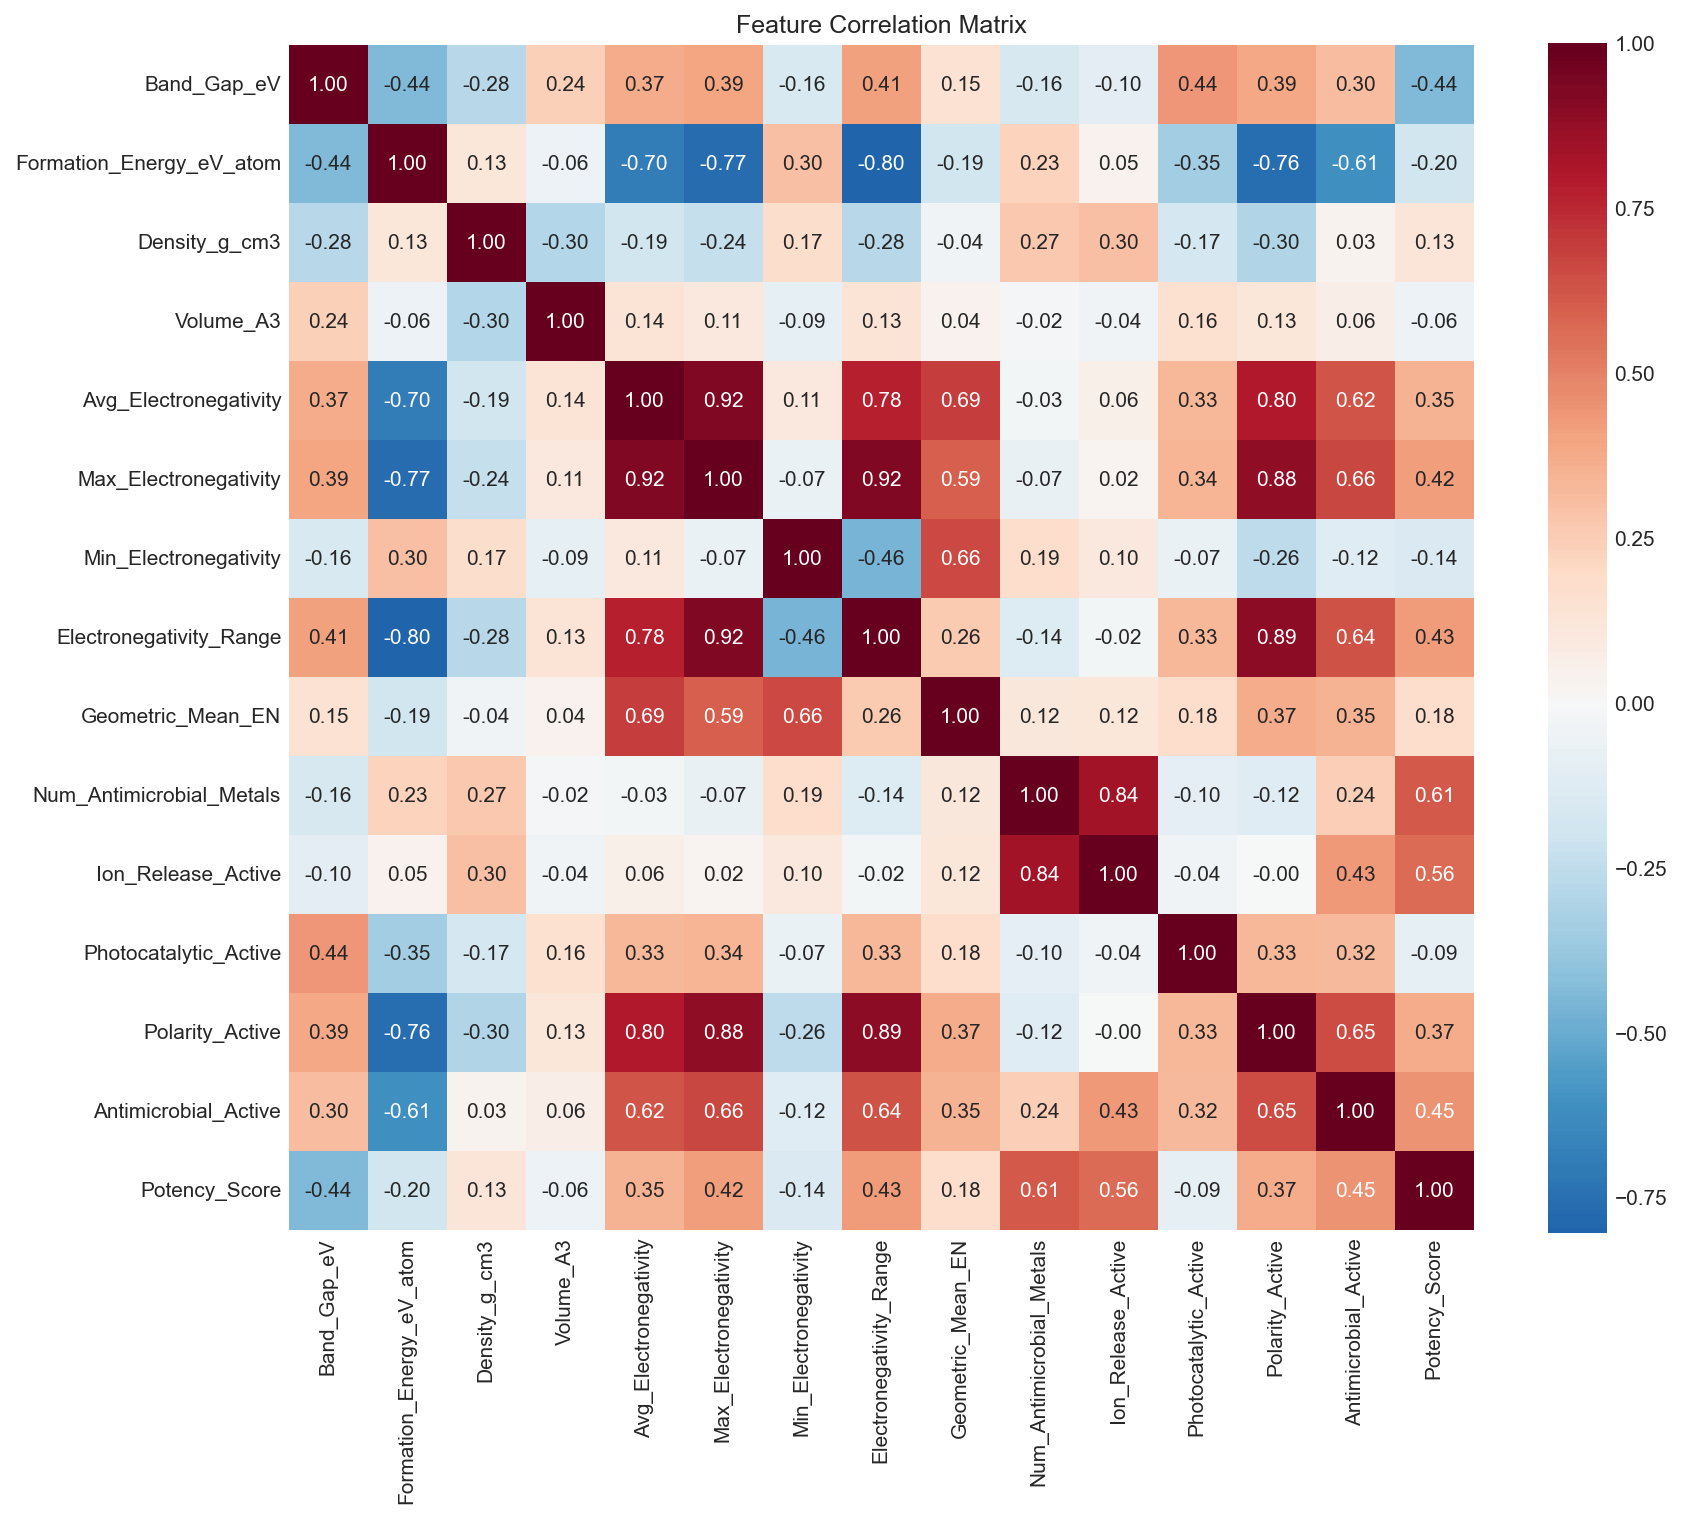

In [11]:
# Define columns of interest (avoid duplicates if any)
numeric_cols = [
    'Band_Gap_eV', 'Formation_Energy_eV_atom', 'Density_g_cm3', 'Volume_A3',
    'Avg_Electronegativity', 'Max_Electronegativity', 'Min_Electronegativity',
    'Electronegativity_Range', 'Geometric_Mean_EN', 'Num_Antimicrobial_Metals',
    'Ion_Release_Active', 'Photocatalytic_Active', 'Polarity_Active',
    'Antimicrobial_Active', 'Potency_Score'
]

# Ensure all exist
available_cols = [col for col in numeric_cols if col in df.columns]
corr = df[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Interpretation**: Potency score correlates positively with `Num_Antimicrobial_Metals` and negatively with band gap (as designed). The mechanism flags show expected patterns: `Ion_Release_Active` correlates with presence of antimicrobial metals; `Photocatalytic_Active` with mid‑range band gaps; `Polarity_Active` with electronegativity range.

### 6.2 Box Plots: Key Features vs. Antimicrobial Activity

Compare distributions of selected descriptors between active and inactive materials.

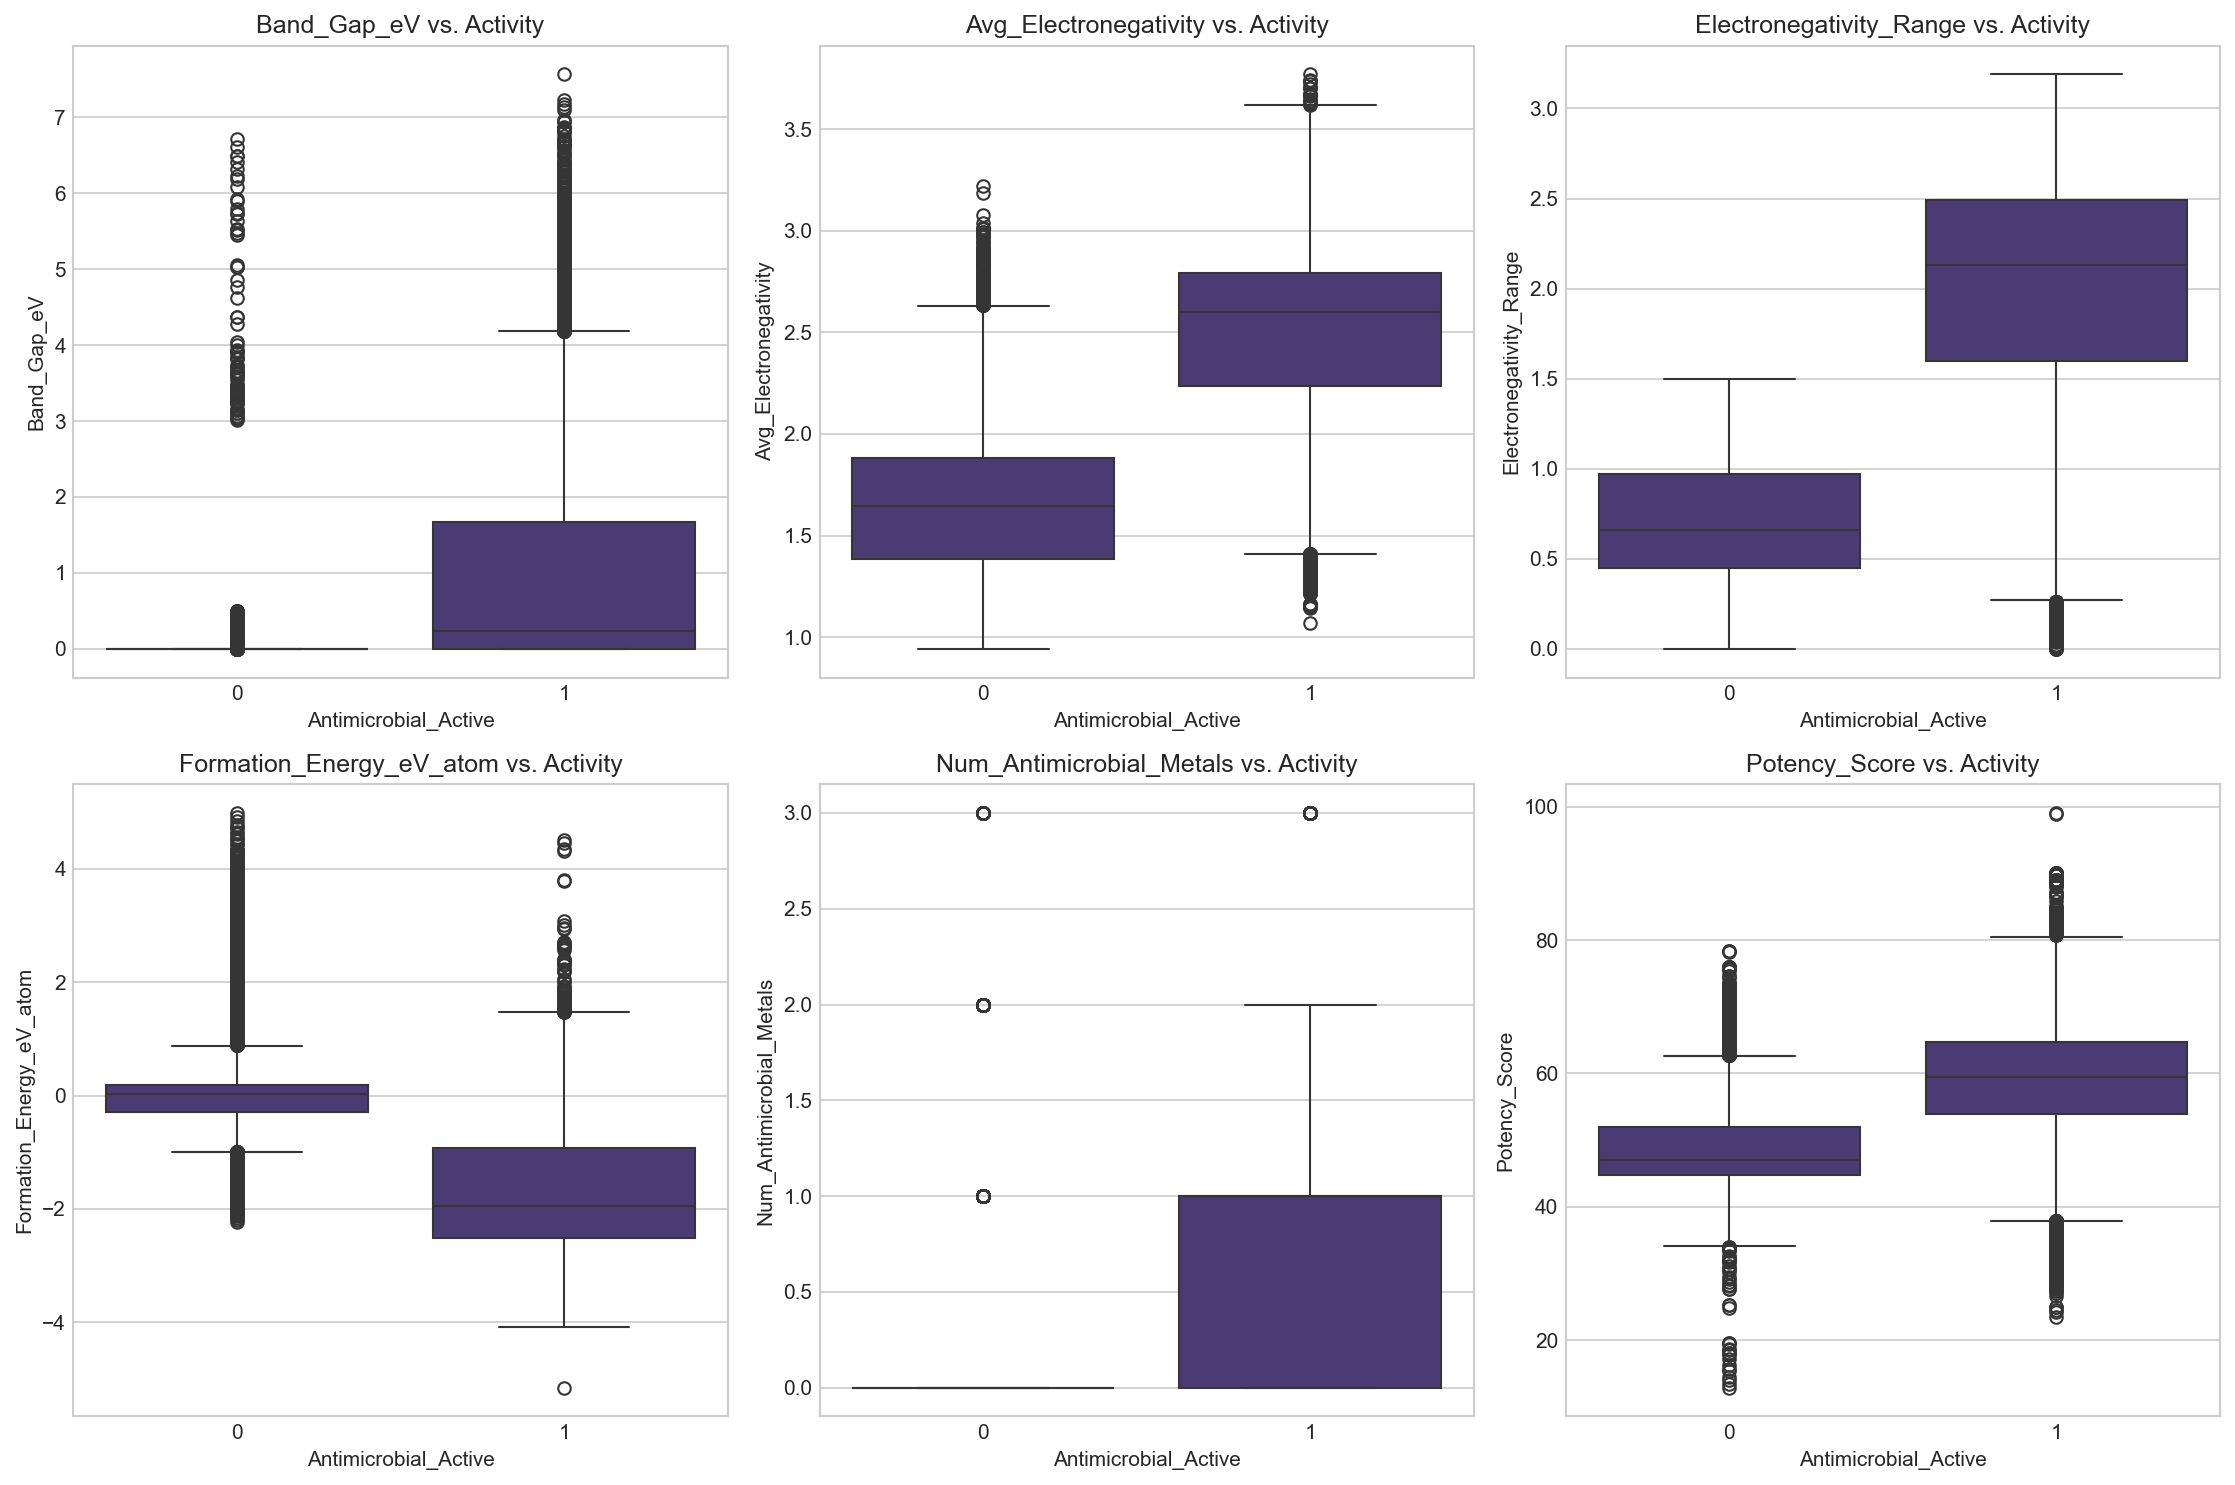

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Band_Gap_eV', 'Avg_Electronegativity', 'Electronegativity_Range', 
            'Formation_Energy_eV_atom', 'Num_Antimicrobial_Metals', 'Potency_Score']

for ax, feat in zip(axes.flat, features):
    sns.boxplot(ax=ax, x='Antimicrobial_Active', y=feat, data=df)
    ax.set_title(f'{feat} vs. Activity')

plt.tight_layout()
plt.show()

### 6.3 Distribution of Potency Scores by Activity Class

Density plot showing separation achieved by the potency score.

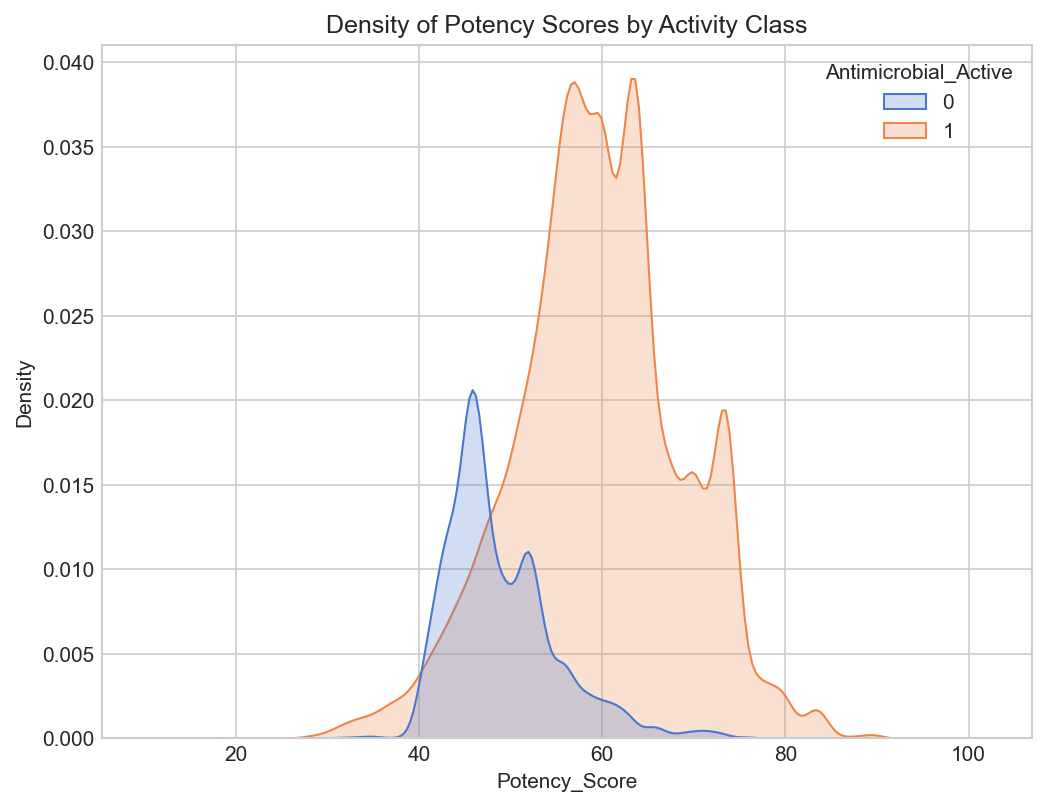

In [13]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Potency_Score', hue='Antimicrobial_Active', fill=True, palette='muted')
plt.title('Density of Potency Scores by Activity Class')
plt.show()

### 6.4 Pair Plot (Sampled)

To avoid overcrowding, we take a random sample of 500 points.

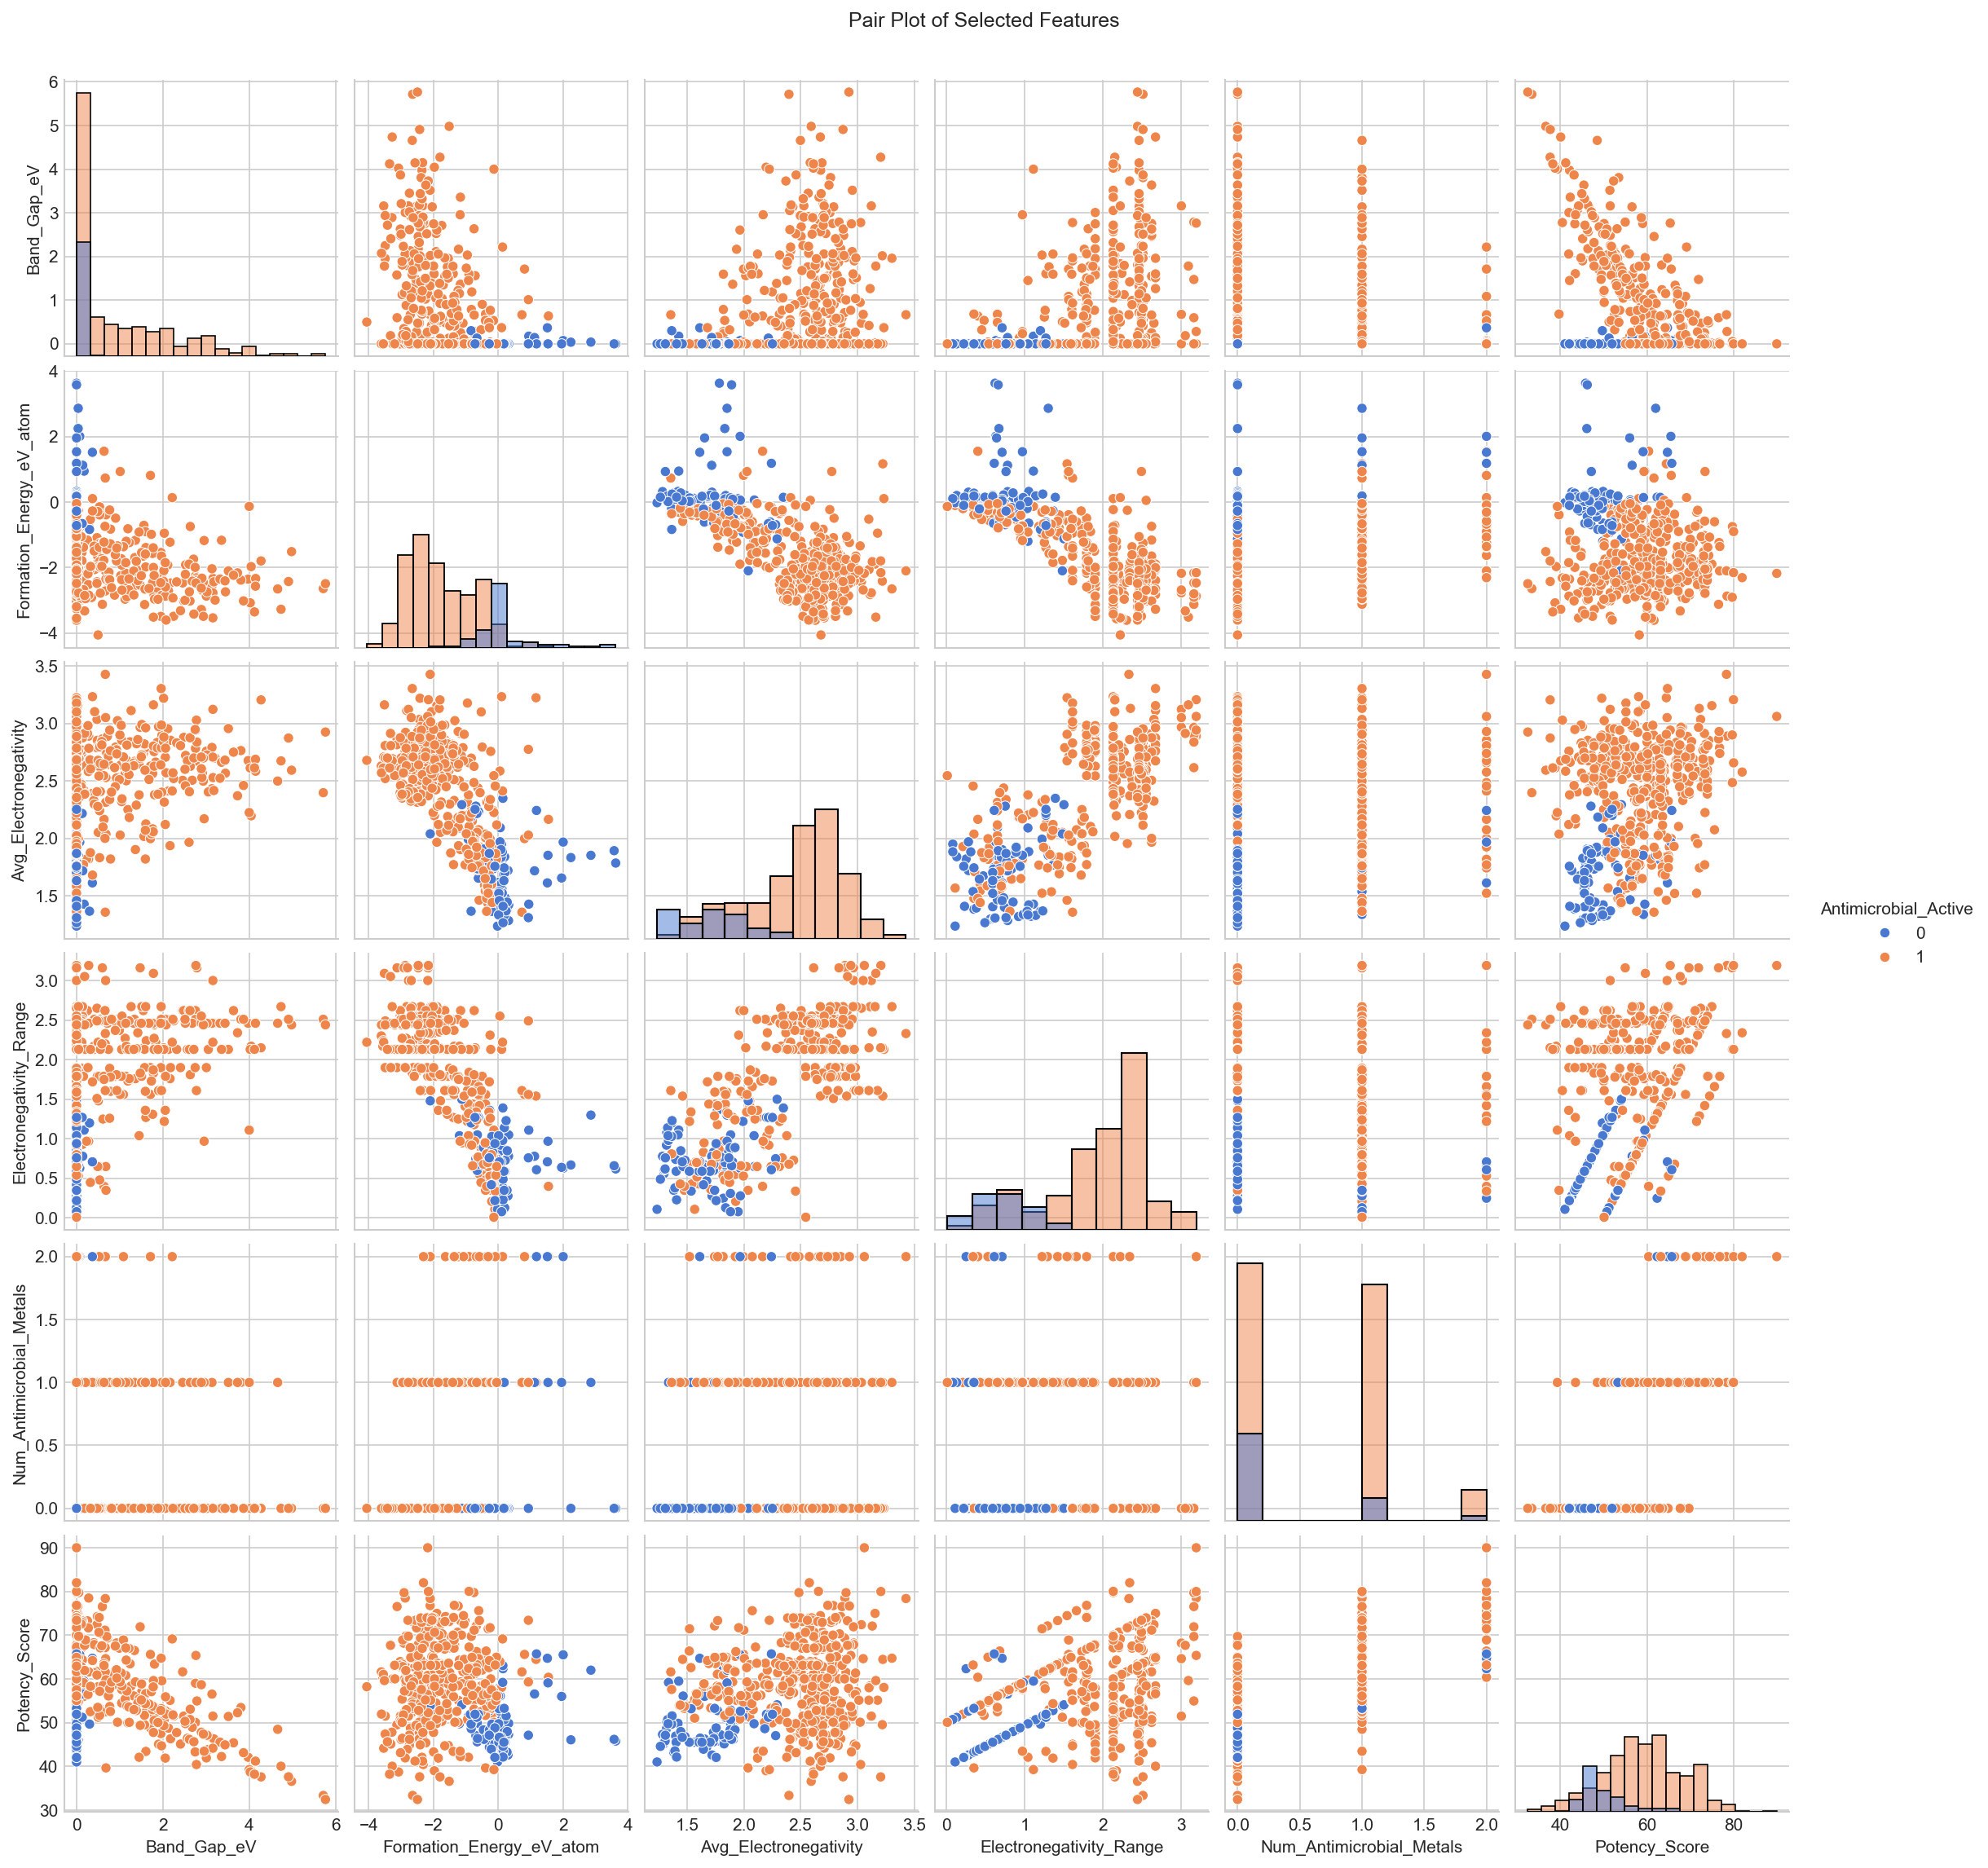

In [14]:
sample_df = df.sample(min(500, len(df)), random_state=42)
pair_vars = ['Band_Gap_eV', 'Formation_Energy_eV_atom', 'Avg_Electronegativity', 
             'Electronegativity_Range', 'Num_Antimicrobial_Metals', 'Potency_Score']
sns.pairplot(sample_df, vars=pair_vars, hue='Antimicrobial_Active', diag_kind='hist', palette='muted')
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

---
## 7. Save the Enriched Dataset

We save the DataFrame with all new features and labels for the next notebook.

In [15]:
output_file = "02_materials_with_features.csv"
df.to_csv(output_file, index=False)
print(f"Enriched data saved to {output_file}")
print(f"Final shape: {df.shape}")
print(f"Columns:\n{df.columns.tolist()}")

Enriched data saved to 02_materials_with_features.csv
Final shape: (55200, 23)
Columns:
['MPID', 'Formula', 'Band_Gap_eV', 'Formation_Energy_eV_atom', 'Density_g_cm3', 'Volume_A3', 'Is_Metal', 'Num_Elements', 'Avg_Atomic_Number', 'Avg_Atomic_Mass', 'Avg_Electronegativity', 'Max_Electronegativity', 'Min_Electronegativity', 'Electronegativity_Range', 'Geometric_Mean_EN', 'Has_Antimicrobial_Metal', 'Num_Antimicrobial_Metals', 'Ion_Release_Active', 'Photocatalytic_Active', 'Polarity_Active', 'Antimicrobial_Active', 'Mechanism_Count', 'Potency_Score']


---
## 8. Discussion of Limitations and Future Improvements

While we have grounded our descriptors and rules in the literature, the following limitations must be acknowledged:

1. **Composition‑only descriptors** cannot capture crystal structure effects (surface chemistry, defects, morphology) that strongly influence antimicrobial activity.
2. **Thresholds** (e.g., band gap < 3 eV, EN range > 1.5) are heuristic; actual activity depends on precise band alignment with biological redox potentials.
3. **Weights** in the potency score are illustrative; true QSAR requires fitting to experimental MIC (minimum inhibitory concentration) data.
4. **Ion release** is oversimplified – dissolution rate depends on surface energy, pH, and passivation layers, not just formation energy.

For future study, these descriptors should be complemented with more **DFT‑calculated properties** (work function, band edge positions, surface energy) and validated against experimental assays. The present workflow serves as a **rapid, interpretable screening** tool that prioritizes candidates for experimental testing.